announcement=Data set deprecation warning: SDSS/BOSS DR16 will be replaced with SDSS/BOSS DR17 starting on or after November 1, 2025


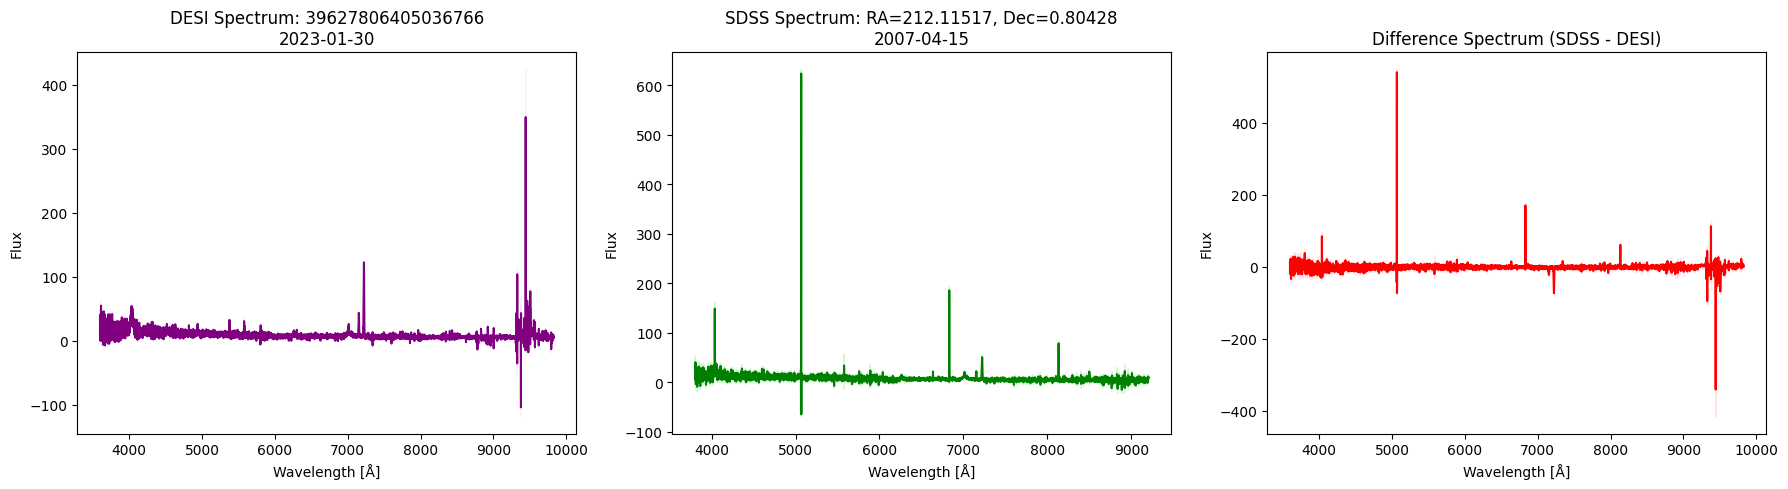

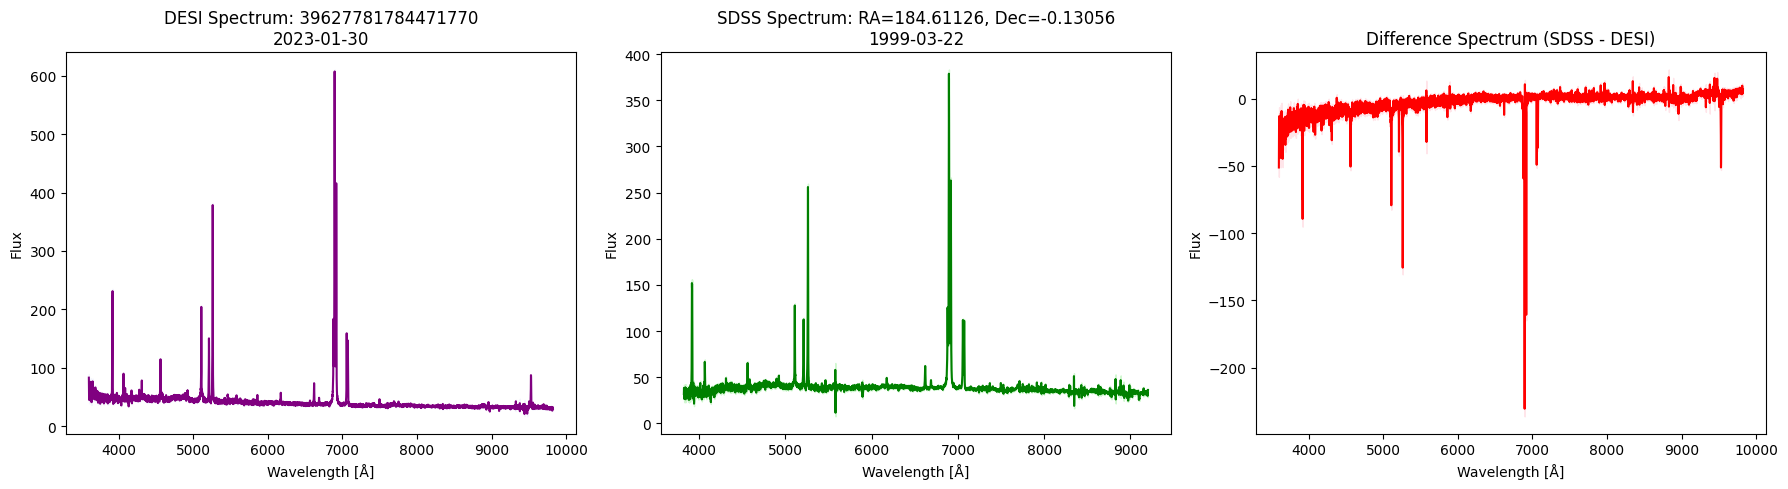

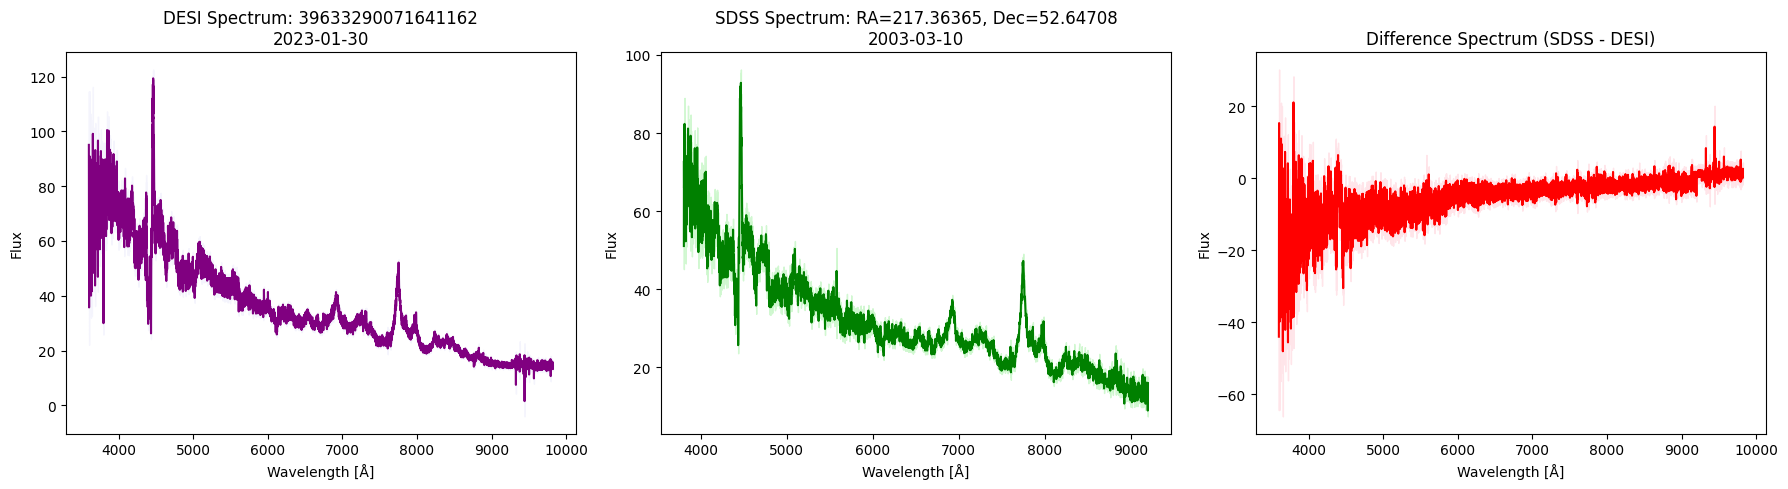

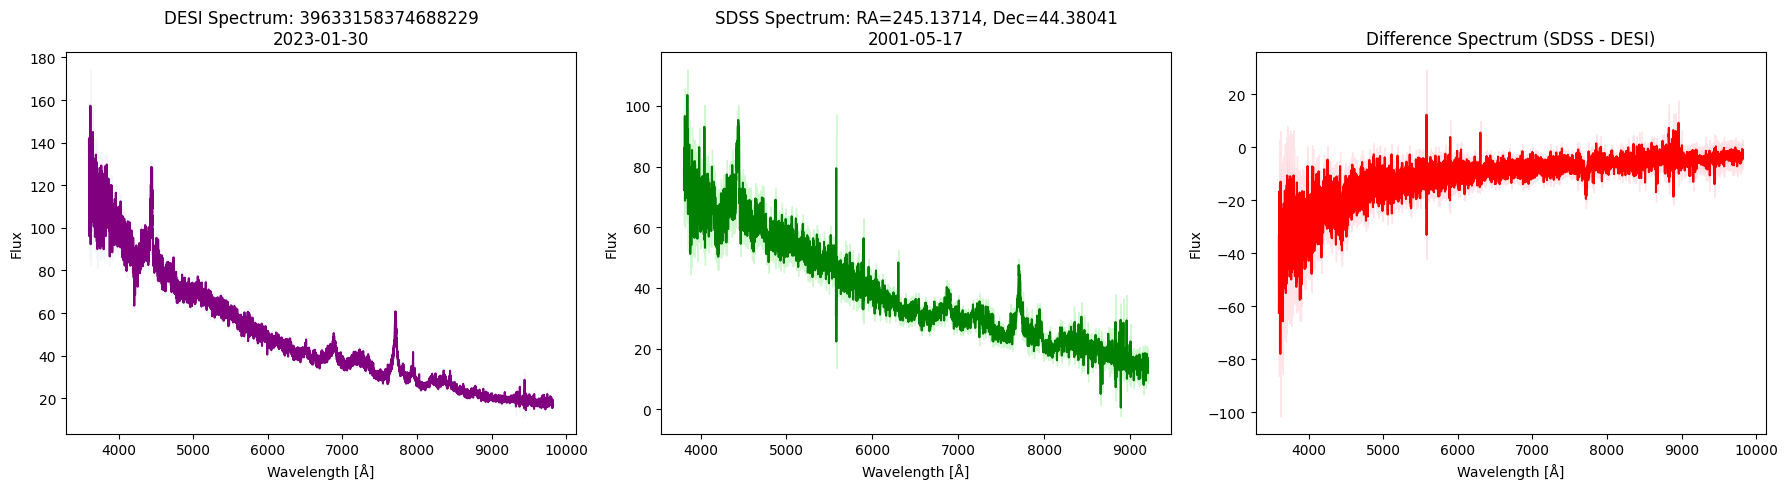

Saved summary to sdss_desi_comparison_summary.csv


/var/folders/ss/b9pkd2ts3xqd_ryqfmgjby1r0000gn/T/ipykernel_39659/3753737899.py:82: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(gaussian, x, y, p0=p0, sigma=yerr, maxfev=5000)


,RA,Dec,TARGETID,SDSS_date,DESI_date,days_diff,years_diff,Hα_SDSS_flux,Hα_SDSS_flux_err,Hα_SDSS_cen,...,Hβ_flux_diff_sigma,[O III]_SDSS_flux,[O III]_SDSS_flux_err,[O III]_SDSS_cen,[O III]_DESI_flux,[O III]_DESI_flux_err,[O III]_DESI_cen,[O III]_flux_diff,[O III]_flux_diff_err,[O III]_flux_diff_sigma
0,212.115173,0.804283,39627806405036766,2007-04-15,2023-01-30,8358.0,22.882957,4.050702e+01,2.561843e+01,6569.794115,...,0.000051,-19.325163,4.069764e+06,5004.390917,-13.022443,5.054698e+05,5006.780797,6.302720,4.101034e+06,0.000002
1,184.611261,-0.130556,39627781784471770,1999-03-22,2023-01-30,7951.0,21.768652,7.055847e+00,5.590381e+00,6565.573081,...,0.208212,-22.576840,1.231087e+01,5003.913427,-9.903524,6.974163e+00,5005.061984,12.673316,1.414908e+01,0.895699
2,217.363650,52.647076,39633290071641162,2003-03-10,2023-01-30,7210.0,19.739904,-7.055918e+06,1.980536e+10,6574.554531,...,-0.011381,-4140.938051,4.177566e+04,5036.473992,-18.971542,1.444199e+01,5006.123459,4121.966509,4.177566e+04,0.098669
3,245.137141,44.380412,39633158374688229,2001-05-17,2023-01-30,7619.0,20.859685,-3.969419e+07,2.675719e+11,6563.586995,...,0.000047,-0.840191,inf,5007.248309,-1.133315,1.208698e+07,5007.182158,-0.293124,inf,-0.000000


In [4]:
# ---------------- Imports ----------------
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings
from astropy import units as u
from astropy import coordinates as coords
from astropy.time import Time
from scipy.ndimage import gaussian_filter1d
from scipy.optimize import curve_fit
from astroquery.sdss import SDSS
from sparcl.client import SparclClient

# Increase timeout (in seconds). Default is 5400, but let's explicitly set it higher if needed
sparcl_client = SparclClient(read_timeout=600)

# ---------- Target objects ----------
# RA, Dec, DESI TARGETID, SDSS date, DESI date
objects = [
    (212.11517269116484, 0.8042832798529206, 39627806405036766, "2007-04-15", "2023-01-30"),
    (184.61126060539436, -0.13055555750871617, 39627781784471770, "1999-03-22", "2023-01-30"),
    (217.36365, 52.647076, 39633290071641162, "2003-03-10", "2023-01-30"),
    (245.13714087266763, 44.380411703728996, 39633158374688229, "2001-05-17", "2023-01-30")
]

# ---------- Lines of interest ----------
LINES = {'Hα': 6563, 'Hβ': 4861, '[O III]': 5007}
WINDOW = 20  # +/- Å around line for fitting

# ---------------- Helpers ----------------
def get_spectrum(targetid):
    """Retrieve DESI spectrum using sparcl_client"""
    res = sparcl_client.find(outfields=['sparcl_id'], constraints={'targetid':[targetid]}, limit=1)
    if len(res.ids)==0:
        return None, None, None
    spec = sparcl_client.retrieve([res.ids[0]], include=['flux','ivar','wavelength','wavemin','wavemax','wave_sigma'])
    rec = spec.records[0]
    flux = np.array(rec['flux'])
    ivar = np.array(rec['ivar'])
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        sigma = np.where(ivar>0, 1/np.sqrt(ivar), np.nan)
    if 'wavelength' in rec:
        wave = np.array(rec['wavelength'])
    else:
        wave = np.arange(rec['wavemin'], rec['wavemax'], rec['wave_sigma'])[:len(flux)]
    return wave, flux, sigma

def parse_sdss_mjd_from_header(spec_hdu):
    hdr = spec_hdu[0].header
    mjd = hdr.get('MJD-OBS') or hdr.get('MJD')
    if mjd is None:
        return None
    try:
        return float(mjd)
    except:
        return None

def time_difference_days(mjd1, mjd2):
    if (mjd1 is None) or (mjd2 is None):
        return np.nan, np.nan
    days = abs(mjd2 - mjd1)
    years = days / 365.25
    return days, years

def gaussian(x, amp, cen, sigma, baseline):
    return baseline + amp * np.exp(-0.5*((x-cen)/sigma)**2)

def fit_line(wave, flux, sigma_flux, rest_wave, window=WINDOW):
    mask = (wave > rest_wave - window) & (wave < rest_wave + window)
    if not np.any(mask):
        return None
    x = wave[mask]
    y = flux[mask]
    yerr = sigma_flux[mask] if sigma_flux is not None else np.full_like(y, np.nanstd(y))
    amp0 = np.nanmax(y) - np.nanmedian(y)
    cen0 = rest_wave
    sigma0 = 3.0
    base0 = np.nanmedian(y)
    p0 = [amp0 if np.isfinite(amp0) else 1.0, cen0, sigma0, base0]
    try:
        popt, pcov = curve_fit(gaussian, x, y, p0=p0, sigma=yerr, maxfev=5000)
        perr = np.sqrt(np.diag(pcov))
        amp, cen, sig, base = popt
        amp_err, cen_err, sig_err, base_err = perr
        integ = amp * sig * np.sqrt(2*np.pi)
        integ_err = np.sqrt((amp_err*sig*np.sqrt(2*np.pi))**2 + (sig_err*amp*np.sqrt(2*np.pi))**2)
        return {'amp':amp,'amp_err':amp_err,'cen':cen,'sigma':sig,'sigma_err':sig_err,
                'baseline':base,'baseline_err':base_err,'integrated_flux':integ,'integrated_flux_err':integ_err}
    except:
        return None

def compute_diff_and_uncertainty(sdss_interp, sdss_err_interp, desi_interp, desi_err):
    if sdss_interp is None or desi_interp is None:
        return None, None
    s_err = sdss_err_interp if sdss_err_interp is not None else np.zeros_like(sdss_interp)
    d_err = desi_err if desi_err is not None else np.zeros_like(desi_interp)
    diff = sdss_interp - desi_interp
    diff_err = np.sqrt(np.nan_to_num(s_err**2, nan=0.0) + np.nan_to_num(d_err**2, nan=0.0))
    return diff, diff_err

# ---------------- Main Loop ----------------
summary_rows = []

for ra, dec, tid, sdss_date_str, desi_date_str in objects:
    pos = coords.SkyCoord(ra, dec, unit=(u.deg, u.deg), frame='icrs')

    # ----- SDSS -----
    xid = SDSS.query_region(pos, spectro=True, radius=2*u.arcsec)
    if xid is not None:
        sdss_spectra = SDSS.get_spectra(matches=xid)
        if sdss_spectra:
            spec = sdss_spectra[0]
            sdss_wave = 10**spec[1].data['loglam']
            sdss_flux = spec[1].data['flux']
            if 'ivar' in spec[1].data.names:
                ivar = spec[1].data['ivar']
                sdss_error = np.zeros_like(ivar)
                mask = ivar>0
                sdss_error[mask] = 1/np.sqrt(ivar[mask])
                sdss_error[~mask] = np.nan
            else:
                sdss_error = None
            # MJD
            try:
                sdss_mjd = parse_sdss_mjd_from_header(spec)
            except:
                sdss_mjd = None
        else:
            sdss_wave, sdss_flux, sdss_error, sdss_mjd = None, None, None, None
    else:
        sdss_wave, sdss_flux, sdss_error, sdss_mjd = None, None, None, None

    # ----- DESI -----
    desi_wave, desi_flux, desi_sigma = get_spectrum(tid)
    desi_mjd = Time(desi_date_str).mjd

    # ----- Time difference -----
    days_diff, years_diff = time_difference_days(sdss_mjd, desi_mjd)

    # ----- Scale DESI to SDSS continuum -----
    if sdss_wave is not None and desi_wave is not None:
        scale = np.nanmedian(sdss_flux)/np.nanmedian(desi_flux)
        desi_flux_scaled = desi_flux*scale
    else:
        desi_flux_scaled = desi_flux

    # ----- Interpolate SDSS onto DESI grid for difference -----
    if sdss_wave is not None and desi_wave is not None:
        sdss_interp = np.interp(desi_wave, sdss_wave, sdss_flux)
        sdss_err_interp = np.interp(desi_wave, sdss_wave, sdss_error) if sdss_error is not None else None
        diff_flux, diff_err = compute_diff_and_uncertainty(sdss_interp, sdss_err_interp, desi_flux_scaled, desi_sigma)
    else:
        diff_flux, diff_err = None, None

    # ----- Plot side-by-side + difference -----
    fig, axs = plt.subplots(1,3, figsize=(18,5))

    if desi_wave is not None:
        axs[0].plot(desi_wave, desi_flux_scaled, color='purple')
        axs[0].fill_between(desi_wave, desi_flux_scaled-desi_sigma, desi_flux_scaled+desi_sigma, color='lavender', alpha=0.4)
        axs[0].set_title(f'DESI Spectrum: {tid}\n{desi_date_str}')
        axs[0].set_xlabel('Wavelength [Å]'); axs[0].set_ylabel('Flux')

    if sdss_wave is not None:
        axs[1].plot(sdss_wave, sdss_flux, color='green')
        if sdss_error is not None:
            axs[1].fill_between(sdss_wave, sdss_flux-sdss_error, sdss_flux+sdss_error, color='lightgreen', alpha=0.4)
        axs[1].set_title(f'SDSS Spectrum: RA={ra:.5f}, Dec={dec:.5f}\n{sdss_date_str}')
        axs[1].set_xlabel('Wavelength [Å]'); axs[1].set_ylabel('Flux')

    if diff_flux is not None:
        axs[2].plot(desi_wave, diff_flux, color='red')
        if diff_err is not None:
            axs[2].fill_between(desi_wave, diff_flux-diff_err, diff_flux+diff_err, color='pink', alpha=0.4)
        axs[2].set_title('Difference Spectrum (SDSS - DESI)')
        axs[2].set_xlabel('Wavelength [Å]'); axs[2].set_ylabel('Flux')

    plt.tight_layout()
    plt.show()

    # ----- Measure lines -----
    row = {'RA':ra,'Dec':dec,'TARGETID':tid,'SDSS_date':sdss_date_str,'DESI_date':desi_date_str,
           'days_diff':days_diff,'years_diff':years_diff}
    for lname, rest in LINES.items():
        sdss_fit = fit_line(sdss_wave, sdss_flux, sdss_error, rest) if sdss_wave is not None else None
        desi_fit = fit_line(desi_wave, desi_flux_scaled, desi_sigma, rest) if desi_wave is not None else None

        for prefix, fit in zip(['SDSS','DESI'], [sdss_fit, desi_fit]):
            if fit is not None:
                row[f'{lname}_{prefix}_flux'] = fit['integrated_flux']
                row[f'{lname}_{prefix}_flux_err'] = fit['integrated_flux_err']
                row[f'{lname}_{prefix}_cen'] = fit['cen']
            else:
                row[f'{lname}_{prefix}_flux'] = np.nan
                row[f'{lname}_{prefix}_flux_err'] = np.nan
                row[f'{lname}_{prefix}_cen'] = np.nan

        # Difference flux
        if sdss_fit is not None and desi_fit is not None:
            diff = desi_fit['integrated_flux'] - sdss_fit['integrated_flux']
            diff_err = np.sqrt(desi_fit['integrated_flux_err']**2 + sdss_fit['integrated_flux_err']**2)
            row[f'{lname}_flux_diff'] = diff
            row[f'{lname}_flux_diff_err'] = diff_err
            row[f'{lname}_flux_diff_sigma'] = diff/diff_err if diff_err>0 else np.nan
        else:
            row[f'{lname}_flux_diff'] = np.nan
            row[f'{lname}_flux_diff_err'] = np.nan
            row[f'{lname}_flux_diff_sigma'] = np.nan

    summary_rows.append(row)

# ---------- Save results ----------
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv("sdss_desi_comparison_summary.csv", index=False)
print("Saved summary to sdss_desi_comparison_summary.csv")
summary_df
